# Feature Validation Plots (Interactive)

This notebook validates extracted features against raw IMU signals for one chosen folder.

You can:
- choose a directory using **tkinter**, or
- use `DATA_ROOT / PATIENT_ID / DATE`.

It supports layouts where activity CSVs are direct or nested. If multiple files match,
it prefers filenames containing `synchronized`.

## Imports

In [1]:
from pathlib import Path
import os
import subprocess
import tkinter as tk
from tkinter import filedialog
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imu_features.config import PipelineConfig
import validation_plots.shared_validation as sv


## Configuration

In [2]:
DATA_ROOT = Path("Data")
PATIENT_ID = "patient_103"
DATE = "2026-03-08"             # e.g. "2026-03-08" or "D1_2025-03-23"; None => latest
ACTIVITY_FILTER = None         # e.g. ["walk", "left_turn"]
USE_TKINTER_CHOOSER = False     # set True to open folder chooser UI

PLOT_PARAMS = {
    "step_min_distance_alpha": 0.5,
    "pause_min_duration_beta": 0.6,
    "plot_walk_histogram": True,
    "walk_variance_window_sec": 0.50,
    "walk_compare_fs_hz": 10,
    "walk_compare_min_amp": 0.30,
    "walk_compare_min_t_sec": 2.0,
    "walk_compare_step_freq_hz": (0.8, 2.3),
    "window_gate": {
        "window_sec": 1.0,
        "walk_min_amp_threshold": 0.30,
        "turn_min_amp_threshold": 0.10,
        "transition_min_amp_threshold": 0.30,
    },
}

COLUMN_MAPPING_OVERRIDE = {
    "timestamp": ["Timestamp", "timestamp", "time", "Time"],
    "accel_x": ["Accel_X", "accel_x", "acc_x"],
    "accel_y": ["Accel_Y", "accel_y", "acc_y"],
    "accel_z": ["Accel_Z", "accel_z", "acc_z"],
    "useracc_x": ["UserAccel_X", "useracc_x", "linacc_x", "linearacc_x"],
    "useracc_y": ["UserAccel_Y", "useracc_y", "linacc_y", "linearacc_y"],
    "useracc_z": ["UserAccel_Z", "useracc_z", "linacc_z", "linearacc_z"],
    "gyro_x": ["Gyro_X", "gyro_x", "gyr_x"],
    "gyro_y": ["Gyro_Y", "gyro_y", "gyr_y"],
    "gyro_z": ["Gyro_Z", "gyro_z", "gyr_z"],
}

PIPELINE_CONFIG = PipelineConfig()
PIPELINE_CONFIG.column_candidates = COLUMN_MAPPING_OVERRIDE
print("Config ready")

Config ready


## Choose Folder With Tkinter (Optional)

In [3]:
CHOSEN_DIR = None

def _activate_notebook_process_for_dialog():
    if os.name != "posix":
        return
    try:
        subprocess.run(
            [
                "osascript",
                "-e",
                (
                    'tell application "System Events" '
                    f'to set frontmost of first process whose unix id is {os.getpid()} to true'
                ),
            ],
            check=False,
            capture_output=True,
            text=True,
        )
    except Exception:
        pass

def choose_directory_tkinter(initial_dir=None):
    try:
        _activate_notebook_process_for_dialog()
        root = tk.Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        root.lift()
        root.focus_force()
        root.update()
        root.update_idletasks()
        try:
            root.eval('tk::PlaceWindow . center')
        except Exception:
            pass
        _activate_notebook_process_for_dialog()
        selected = filedialog.askdirectory(
            parent=root,
            initialdir=str(Path(initial_dir or DATA_ROOT).resolve()),
            title="Choose activity date folder",
            mustexist=True,
        )
        root.attributes("-topmost", False)
        root.destroy()
        return Path(selected) if selected else None
    except Exception as exc:
        print(f"tkinter chooser unavailable ({exc}); using configured path.")
        return None

CHOSEN_DIR = choose_directory_tkinter(initial_dir=DATA_ROOT) if USE_TKINTER_CHOOSER else None
print("Chosen directory:", CHOSEN_DIR)


Chosen directory: None


## Activity Dropdown

In [4]:
SELECTED_ACTIVITIES = ACTIVITY_FILTER
print("SELECTED_ACTIVITIES:", SELECTED_ACTIVITIES)


SELECTED_ACTIVITIES: None


## Helpers

In [5]:
import validation_plots.shared_validation as sv

sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)

resolve_date_dir = sv.resolve_date_dir
discover_activity_files = sv.discover_activity_files
load_activity_file = sv.load_activity_file
plot_walk_validation = sv.plot_walk_validation
plot_turn_validation = sv.plot_turn_validation
plot_transition_validation = sv.plot_transition_validation
plot_turn_symmetry_comparison = sv.plot_turn_symmetry_comparison
plot_turn_pair_xcorr = sv.plot_turn_pair_xcorr
plot_transition_pair_xcorr = sv.plot_transition_pair_xcorr

print("shared_validation helpers imported")


shared_validation helpers imported


## Base Directory

In [6]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)

if CHOSEN_DIR is not None:
    BASE_DIR = Path(CHOSEN_DIR)
else:
    BASE_DIR = resolve_date_dir(DATA_ROOT, PATIENT_ID, DATE)
    if DATE is None:
        DATE = BASE_DIR.name

print("Base directory:", BASE_DIR)


Base directory: Data/patient_103/2026-03-08


## Walk

Discovered activity files:
  walk: Data/patient_103/2026-03-08/walk.csv

[PROCESS] walk: Data/patient_103/2026-03-08/walk.csv


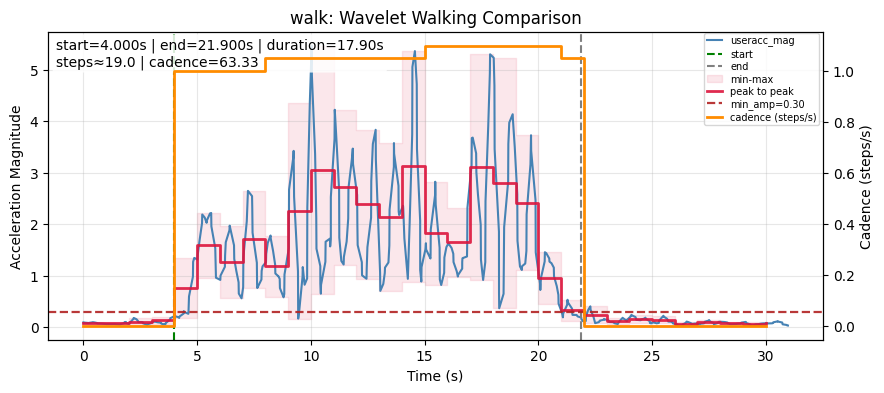

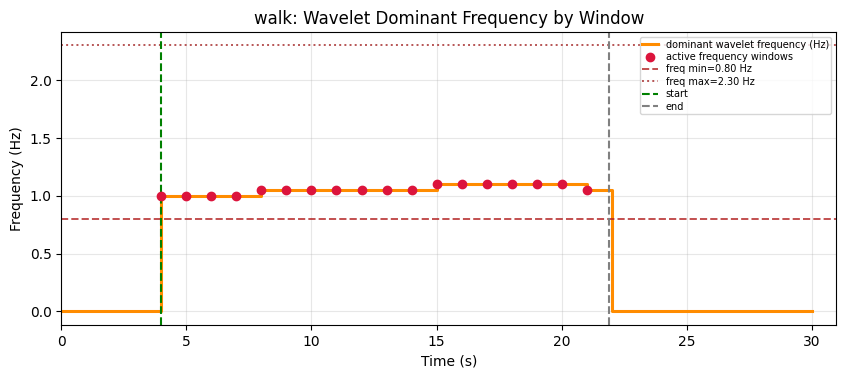

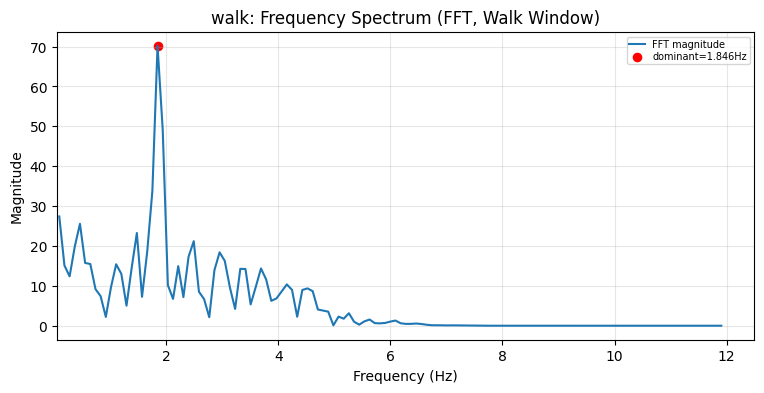

{'activity': 'walk', 'start_time_s': 4.0, 'end_time_s': 21.900000000000002, 'duration_s': 17.900000000000002, 'step_count': 19.00000000000001, 'cadence': 63.33333333333337}


,activity,start_time_s,end_time_s,duration_s,step_count,cadence
0,walk,4.0,21.9,17.9,19.0,63.333333


In [7]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)
activity_files = discover_activity_files(BASE_DIR, ["walk"])
print("Discovered activity files:")
for k, v in activity_files.items():
    print(f"  {k}: {v}")
walk_summaries = []
if "walk" in activity_files:
    path = activity_files["walk"]
    print(f"\n[PROCESS] walk: {path}")
    df, meta = load_activity_file(path)
    summary = plot_walk_validation("walk", df, meta)
    walk_summaries.append(summary)
    print(summary)
else:
    print("[SKIP] walk: not available")
display(pd.DataFrame(walk_summaries))


## Left Turn

Discovered activity files:
  left_turn: Data/patient_103/2026-03-08/left_turn.csv

[PROCESS] left_turn: Data/patient_103/2026-03-08/left_turn.csv


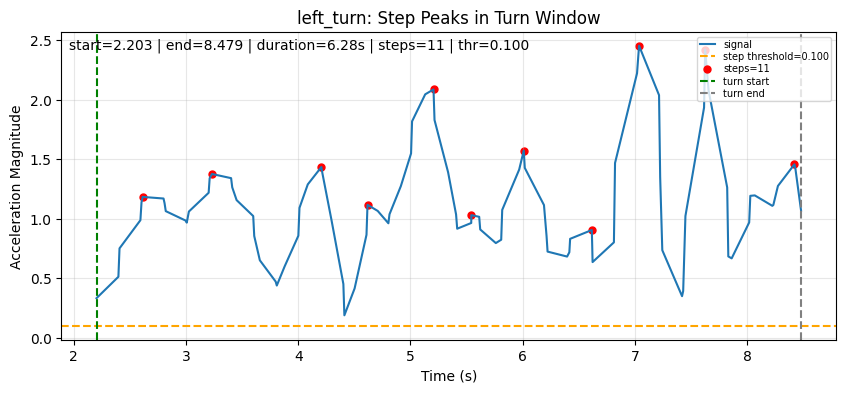

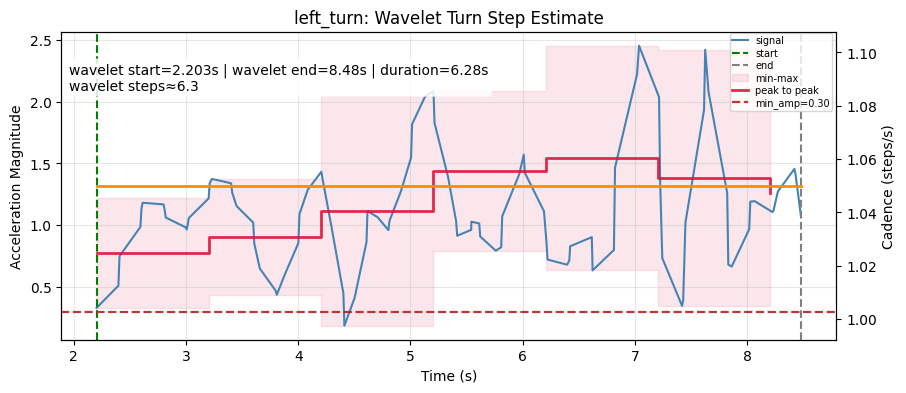

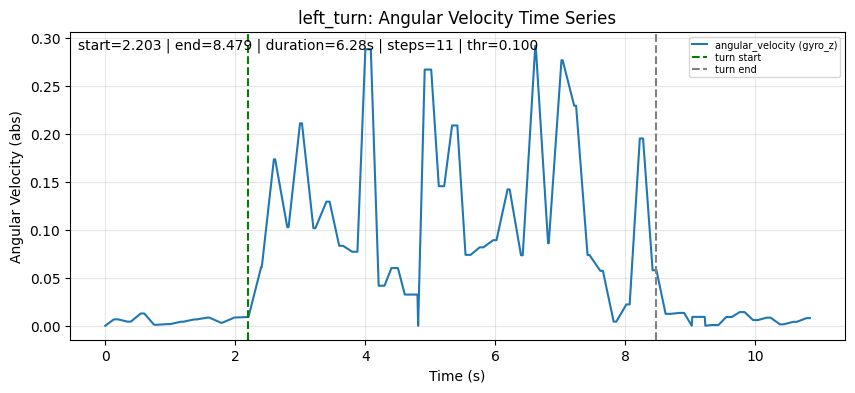

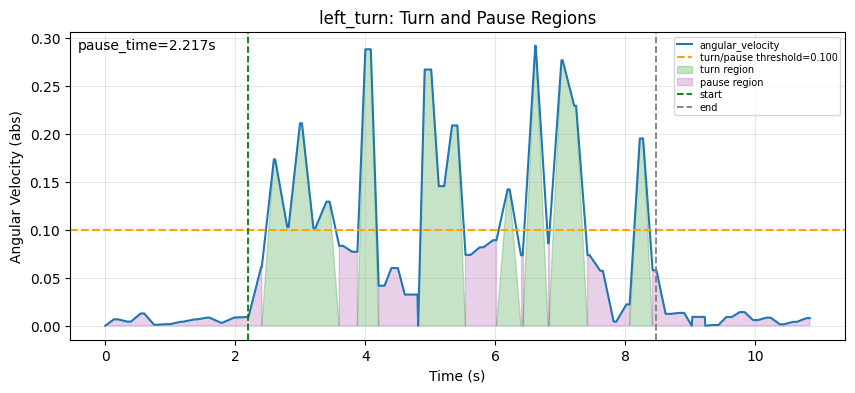

{'activity': 'left_turn', 'start_time_s': 2.203000068664551, 'end_time_s': 8.479000091552734, 'duration_s': 6.276000022888184, 'step_count': 11, 'wavelet_step_count': 6.300000000000003, 'wavelet_cadence': 60.22944528703913}


,activity,start_time_s,end_time_s,duration_s,step_count,wavelet_step_count,wavelet_cadence
0,left_turn,2.203,8.479,6.276,11,6.3,60.229445


In [8]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)
activity_files = discover_activity_files(BASE_DIR, ["left_turn"])
print("Discovered activity files:")
for k, v in activity_files.items():
    print(f"  {k}: {v}")
left_turn_summary = None
left_turn_cache = None
if "left_turn" in activity_files:
    path = activity_files["left_turn"]
    print(f"\n[PROCESS] left_turn: {path}")
    df, meta = load_activity_file(path)
    left_turn_summary, left_turn_cache = plot_turn_validation("left_turn", df, meta)
    print(left_turn_summary)
    display(pd.DataFrame([left_turn_summary]))
else:
    print("[SKIP] left_turn: not available")


## Right Turn

Discovered activity files:
  right_turn: Data/patient_103/2026-03-08/right_turn.csv

[PROCESS] right_turn: Data/patient_103/2026-03-08/right_turn.csv


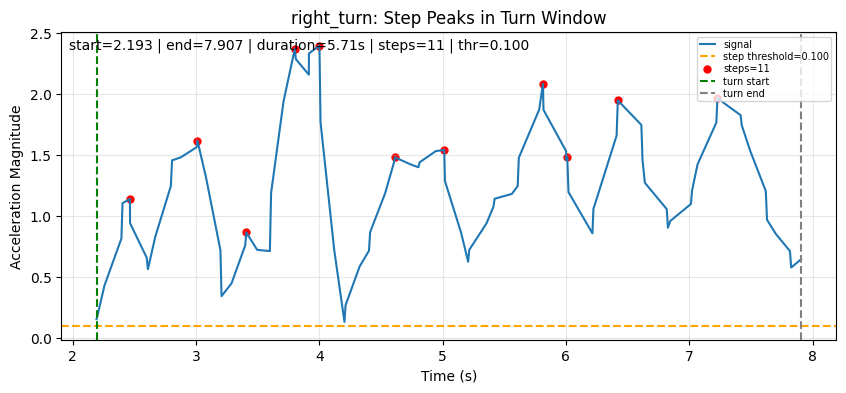

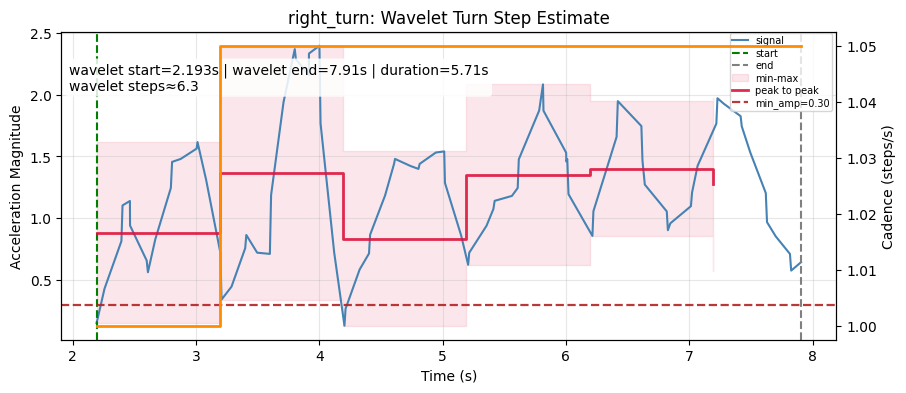

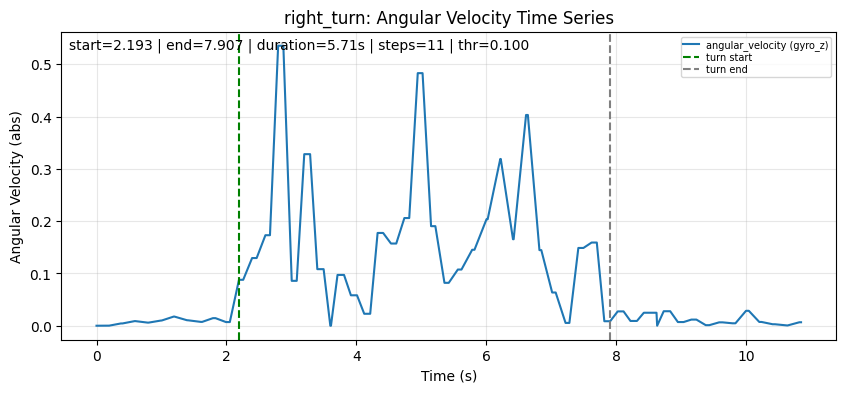

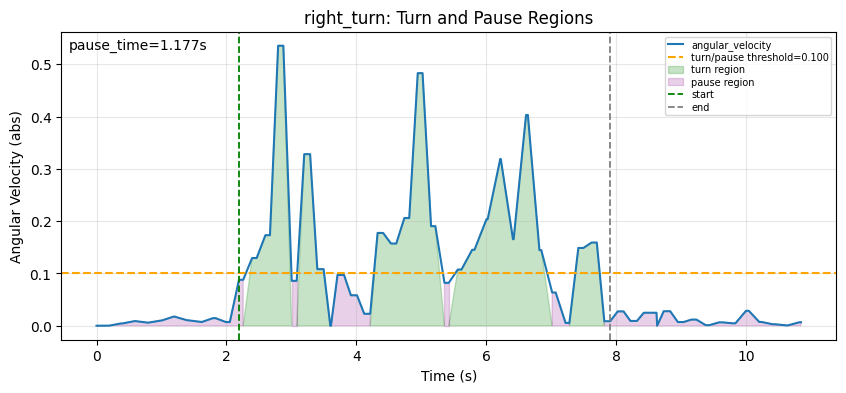

{'activity': 'right_turn', 'start_time_s': 2.193000078201294, 'end_time_s': 7.9070000648498535, 'duration_s': 5.71399998664856, 'step_count': 11, 'wavelet_step_count': 6.2500000000000036, 'wavelet_cadence': 65.62828156741902}


,activity,start_time_s,end_time_s,duration_s,step_count,wavelet_step_count,wavelet_cadence
0,right_turn,2.193,7.907,5.714,11,6.25,65.628282


In [9]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)
activity_files = discover_activity_files(BASE_DIR, ["right_turn"])
print("Discovered activity files:")
for k, v in activity_files.items():
    print(f"  {k}: {v}")
right_turn_summary = None
right_turn_cache = None
if "right_turn" in activity_files:
    path = activity_files["right_turn"]
    print(f"\n[PROCESS] right_turn: {path}")
    df, meta = load_activity_file(path)
    right_turn_summary, right_turn_cache = plot_turn_validation("right_turn", df, meta)
    print(right_turn_summary)
    display(pd.DataFrame([right_turn_summary]))
else:
    print("[SKIP] right_turn: not available")


## Turn Comparisons

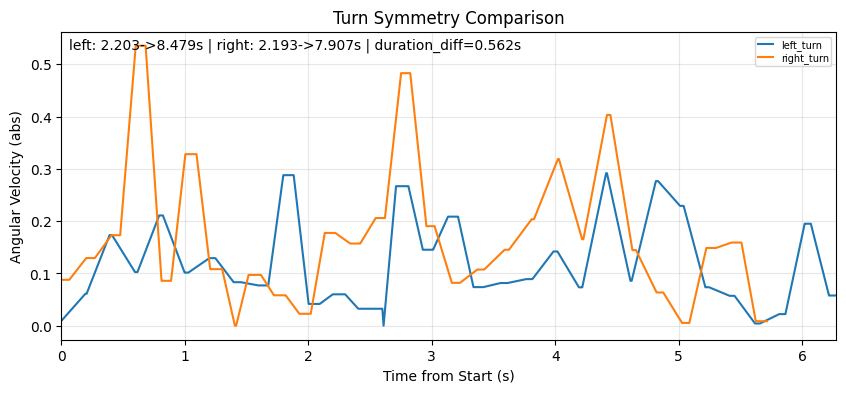

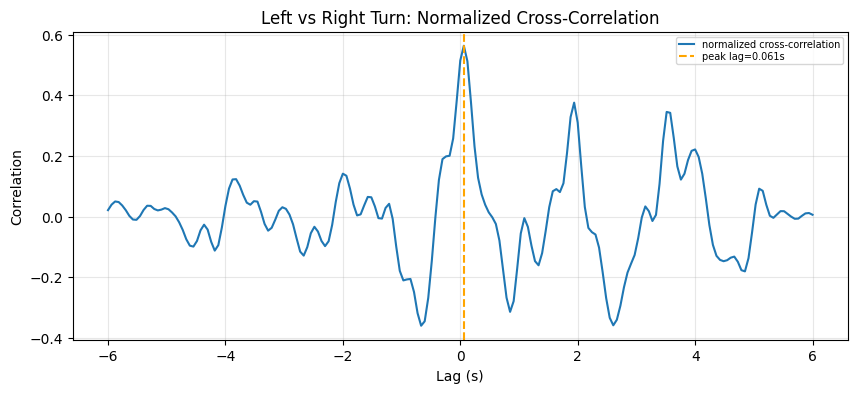

{'activity': 'turn_left_right_xcorr', 'xcorr_peak': 0.5631881622166016, 'xcorr_peak_lag_s': 0.060555555603720924}


,activity,xcorr_peak,xcorr_peak_lag_s
0,turn_left_right_xcorr,0.563188,0.060556


In [10]:
turn_comparisons = []
if left_turn_cache is not None and right_turn_cache is not None:
    plot_turn_symmetry_comparison(left_turn_cache, right_turn_cache)
    turn_corr = plot_turn_pair_xcorr(left_turn_cache, right_turn_cache)
    turn_comparisons.append(turn_corr)
    print(turn_corr)
else:
    print("[SKIP] turn comparisons: need both left_turn and right_turn")
display(pd.DataFrame(turn_comparisons))


## Sit To Stand

Discovered activity files:
  sit_to_stand: Data/patient_103/2026-03-08/sit_to_stand.csv

[PROCESS] sit_to_stand: Data/patient_103/2026-03-08/sit_to_stand.csv


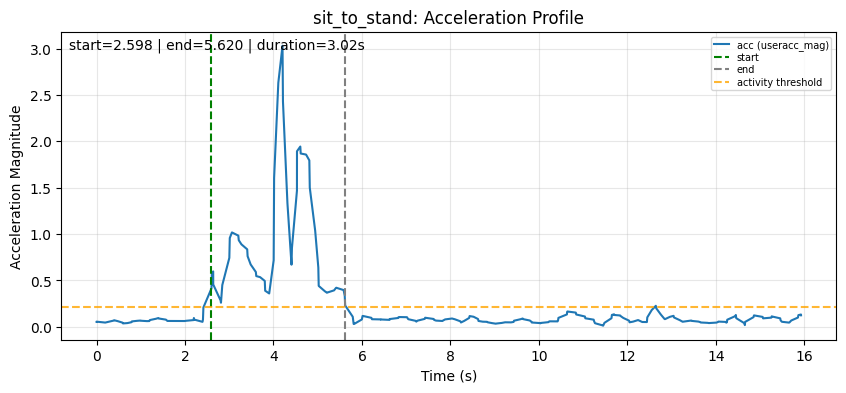

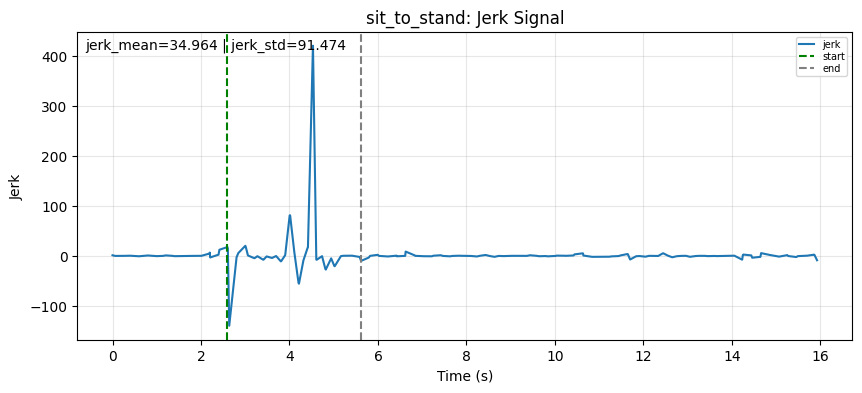

{'activity': 'sit_to_stand', 'start_time_s': 2.5979998111724854, 'end_time_s': 5.619999885559082, 'duration_s': 3.0220000743865967}


,activity,start_time_s,end_time_s,duration_s
0,sit_to_stand,2.598,5.62,3.022


In [11]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)
activity_files = discover_activity_files(BASE_DIR, ["sit_to_stand"])
print("Discovered activity files:")
for k, v in activity_files.items():
    print(f"  {k}: {v}")
sit_to_stand_summary = None
sit_to_stand_cache = None
if "sit_to_stand" in activity_files:
    path = activity_files["sit_to_stand"]
    print(f"\n[PROCESS] sit_to_stand: {path}")
    df, meta = load_activity_file(path)
    sit_to_stand_summary, sit_to_stand_cache = plot_transition_validation("sit_to_stand", df, meta)
    print(sit_to_stand_summary)
    display(pd.DataFrame([sit_to_stand_summary]))
else:
    print("[SKIP] sit_to_stand: not available")


## Stand To Sit

Discovered activity files:
  stand_to_sit: Data/patient_103/2026-03-08/stand_to_sit.csv

[PROCESS] stand_to_sit: Data/patient_103/2026-03-08/stand_to_sit.csv


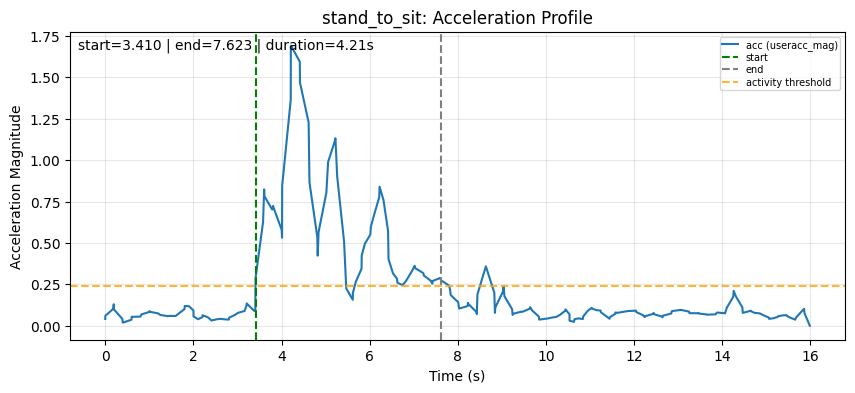

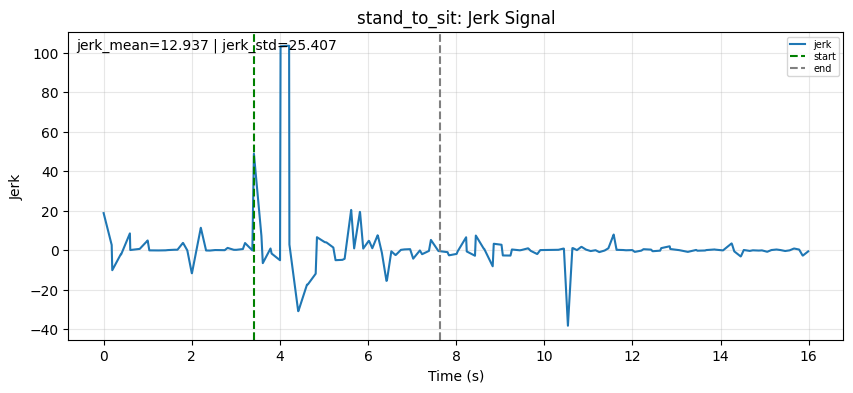

{'activity': 'stand_to_sit', 'start_time_s': 3.4100000858306885, 'end_time_s': 7.623000144958496, 'duration_s': 4.213000059127808}


,activity,start_time_s,end_time_s,duration_s
0,stand_to_sit,3.41,7.623,4.213


In [12]:
sv.configure(PIPELINE_CONFIG, PLOT_PARAMS)
activity_files = discover_activity_files(BASE_DIR, ["stand_to_sit"])
print("Discovered activity files:")
for k, v in activity_files.items():
    print(f"  {k}: {v}")
stand_to_sit_summary = None
stand_to_sit_cache = None
if "stand_to_sit" in activity_files:
    path = activity_files["stand_to_sit"]
    print(f"\n[PROCESS] stand_to_sit: {path}")
    df, meta = load_activity_file(path)
    stand_to_sit_summary, stand_to_sit_cache = plot_transition_validation("stand_to_sit", df, meta)
    print(stand_to_sit_summary)
    display(pd.DataFrame([stand_to_sit_summary]))
else:
    print("[SKIP] stand_to_sit: not available")


## Transition Comparison

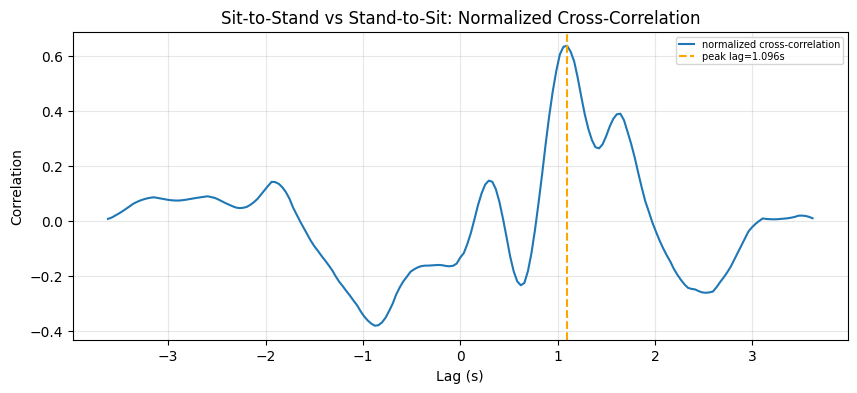

{'activity': 'sitstand_standsit_xcorr', 'xcorr_peak': 0.6358208514880264, 'xcorr_peak_lag_s': 1.0962121414415764}


,activity,xcorr_peak,xcorr_peak_lag_s
0,sitstand_standsit_xcorr,0.635821,1.096212


In [13]:
transition_comparisons = []
if sit_to_stand_cache is not None and stand_to_sit_cache is not None:
    trans_corr = plot_transition_pair_xcorr(sit_to_stand_cache, stand_to_sit_cache)
    transition_comparisons.append(trans_corr)
    print(trans_corr)
else:
    print("[SKIP] transition comparison: need both sit_to_stand and stand_to_sit")
display(pd.DataFrame(transition_comparisons))
